# Quantium Virtual Internship - Retail Strategy and Analytics
# Trial Store Analysis

**Prepared by:** Vivian Nguyen 

**Dataset:** QVI Data

**Objective:** Evaluate the impact of the new trial store layouts by comparing each trial store’s performance against suitable control stores, determine whether the trials were successful, and provide clear, data-driven recommendations for rollout decisions.

In [1]:
# Load libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime 
from scipy import stats

In [2]:
# Read data files into dataframes
df = pd.read_csv('QVI_data.csv')
df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream
...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget


 The client has selected three stores 77, 86 and 88 to be trailed in the period from Feb to April 2019. The client also wants control stores to be established stores that are operational for the entire observation period. 

To evaluate the trial impact, we must select appropriate control stores—stores whose performance closely resembles the trial stores before the trial period.

To ensure fair comparison, control stores must:
- Be fully operational for the entire observation window
- Have complete monthly data prior to the trial period
- Show similar trends in:
  -  Monthly total sales revenue
  -  Monthly number of customers
  -  Average number of transactions per customer

To begin this process, our first task is to prepare the dataset by creating the required time-based column.
We add a `YEAR_MONTH` field, which allows us to aggregate and compare performance across stores on a monthly basis.

 

In [3]:
# Change DATE column to store dates as datetimes 
df['DATE'] = pd.to_datetime(df['DATE'])

# Then add a YEARMONTH column
df['YEARMONTH'] = df['DATE'].dt.strftime('%Y%m').astype('int64')
df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream,201812
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium,201810
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget,201810
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget,201810


After preparing the time-based column, the next step is to build a reusable function that computes the key performance metrics required for comparing trial and control stores.

To support the selection of suitable control stores, we will build a function that generates the required monthly performance metrics for each store. 

This function will calculate all key indicators on per-store, per-month basis, including:
- Monthly total sales revenue 
- Monthly number of unique customers 
- Monthly number of transactions per customer

These metrics provide a consistent month-to-month view of store performance and will form the basis for comparing trial stores against potential control stores during the pre-trial period.

First, adding a column with the year/month of the transaction

In [4]:
# Change Date column to store dates as datetimes
df['DATE'] = pd.to_datetime(df['DATE'])

# Then add a YEARMONTH column
df['YEARMONTH'] = df['DATE'].dt.strftime('%Y%m').astype('int64')
df

,LYLTY_CARD_NBR,DATE,STORE_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,PACK_SIZE,BRAND,LIFESTAGE,PREMIUM_CUSTOMER,YEARMONTH
0,1000,2018-10-17,1,1,5,Natural Chip Compny SeaSalt175g,2,6.0,175,NATURAL,YOUNG SINGLES/COUPLES,Premium,201810
1,1002,2018-09-16,1,2,58,Red Rock Deli Chikn&Garlic Aioli 150g,1,2.7,150,RRD,YOUNG SINGLES/COUPLES,Mainstream,201809
2,1003,2019-03-07,1,3,52,Grain Waves Sour Cream&Chives 210G,1,3.6,210,GRNWVES,YOUNG FAMILIES,Budget,201903
3,1003,2019-03-08,1,4,106,Natural ChipCo Hony Soy Chckn175g,1,3.0,175,NATURAL,YOUNG FAMILIES,Budget,201903
4,1004,2018-11-02,1,5,96,WW Original Stacked Chips 160g,1,1.9,160,WOOLWORTHS,OLDER SINGLES/COUPLES,Mainstream,201811
...,...,...,...,...,...,...,...,...,...,...,...,...,...
264829,2370701,2018-12-08,88,240378,24,Grain Waves Sweet Chilli 210g,2,7.2,210,GRNWVES,YOUNG FAMILIES,Mainstream,201812
264830,2370751,2018-10-01,88,240394,60,Kettle Tortilla ChpsFeta&Garlic 150g,2,9.2,150,KETTLE,YOUNG FAMILIES,Premium,201810
264831,2370961,2018-10-24,88,240480,70,Tyrrells Crisps Lightly Salted 165g,2,8.4,165,TYRRELLS,OLDER FAMILIES,Budget,201810
264832,2370961,2018-10-27,88,240481,65,Old El Paso Salsa Dip Chnky Tom Ht300g,2,10.2,300,OLD,OLDER FAMILIES,Budget,201810


Next, we will create a reusable function that calculates all key monthly performance metrics for each store, including total sales, number of customers, transactions per customer, chips units per customer, and the average price per unit.

In [5]:
# Calculate key monthly performance metrics for each store
# Group data by Store_NBR and YearMonth 
grouped_df = df.groupby(["STORE_NBR", "YEARMONTH"])

# Define and calculate metrics

# Total sales revenue for the month
tot_sales = grouped_df['TOT_SALES'].sum()

# Number of unique customers in the month
n_cust = grouped_df['LYLTY_CARD_NBR'].nunique()

# Number of transactions per customer:
ntrans_percust = grouped_df['TXN_ID'].size() / n_cust

# Chips units per transaction:
nchips_pertrans = grouped_df['PROD_QTY'].sum() / grouped_df['TXN_ID'].size()

# Average price per unit:
avg_priceperunit = tot_sales / grouped_df['PROD_QTY'].sum()


In [6]:
# Combine all metrics into a single dataframe
metric_arrays = [
    tot_sales,
    n_cust,
    ntrans_percust,
    nchips_pertrans,
    avg_priceperunit
]

metrics_df = pd.concat(metric_arrays, axis=1)

# Assign clear column names
metrics_df.columns = [
    'tot_sales',
    'n_cust',
    'ntrans_percust',
    'nchips_pertrans',
    'avg_priceperunit'
]

# Reset index for clean table format
metrics_df = metrics_df.reset_index()

# Display the final metrics table
metrics_df

,STORE_NBR,YEARMONTH,tot_sales,n_cust,ntrans_percust,nchips_pertrans,avg_priceperunit
0,1,201807,206.9,49,1.061224,1.192308,3.337097
1,1,201808,176.1,42,1.023810,1.255814,3.261111
2,1,201809,278.8,59,1.050847,1.209677,3.717333
3,1,201810,188.1,44,1.022727,1.288889,3.243103
4,1,201811,192.6,46,1.021739,1.212766,3.378947
...,...,...,...,...,...,...,...
3164,272,201902,395.5,45,1.066667,1.895833,4.346154
3165,272,201903,442.3,50,1.060000,1.905660,4.379208
3166,272,201904,445.1,54,1.037037,1.875000,4.239048
3167,272,201905,314.6,34,1.176471,1.775000,4.430986


In [7]:
# Filter to select the stores with full observation periods 
month_counts = metrics_df.groupby('STORE_NBR').YEARMONTH.nunique().reset_index()
stores_fullobs = month_counts[month_counts.YEARMONTH ==12].STORE_NBR
pretrial_metrics = metrics_df[metrics_df['STORE_NBR'].isin(stores_fullobs)]
# Then filter to keep only the pre-trial period data
pretrial_metrics = metrics_df.loc[metrics_df.YEARMONTH < 201902]
pretrial_metrics

,STORE_NBR,YEARMONTH,tot_sales,n_cust,ntrans_percust,nchips_pertrans,avg_priceperunit
0,1,201807,206.9,49,1.061224,1.192308,3.337097
1,1,201808,176.1,42,1.023810,1.255814,3.261111
2,1,201809,278.8,59,1.050847,1.209677,3.717333
3,1,201810,188.1,44,1.022727,1.288889,3.243103
4,1,201811,192.6,46,1.021739,1.212766,3.378947
...,...,...,...,...,...,...,...
3159,272,201809,304.7,32,1.125000,1.972222,4.291549
3160,272,201810,430.6,44,1.159091,1.941176,4.349495
3161,272,201811,376.2,41,1.097561,1.933333,4.324138
3162,272,201812,403.9,47,1.000000,1.893617,4.538202


Now that we have created the monthly performance metrics, the next step is to assess how similar each potential control store is to the trial store.

In [8]:
def calc_corr(trial, metric_cols, input_table=pretrial_metrics):
    """
    trial        : int, trial store ID
    metric_cols  : list of metric column names
    input_table  : pre-trial metrics table

    Returns:
        corr_table: df with YEAR-MONTH, trial_store, control_store, correlation
    """

    trial_stores = [77, 86, 88]

    # Control stores = stores with full pre-trial months, excluding trial stores
    control_stores = stores_fullobs[~stores_fullobs.isin(trial_stores)]

    # Keep the trial store values for correlation
    trial_vals = (
        input_table[input_table["STORE_NBR"] == trial]
        .sort_values("YEARMONTH")[metric_cols]
        .reset_index()
    )

    corr_table = pd.DataFrame(columns = ['YEARMONTH', 'trial_store', 'control_store', 'correlation']) 

    # ------------------------------------------------------------
    # Compute correlation per month between trial and each control
    # ------------------------------------------------------------
    for control in control_stores:
        control_vals = input_table[input_table["STORE_NBR"] == control][metric_cols].reset_index()
        corr_row = pd.DataFrame(columns = ['YEARMONTH', 'trial_store', 'control_store', 'correlation'])

        # Control store values
        control_vals = (
            input_table[input_table["STORE_NBR"] == control]
            .sort_values("YEARMONTH")[metric_cols]
            .reset_index()
        )

        # YEAR-MONTH for this control store
        corr_row.YEARMONTH = list(
            input_table.
            loc[input_table.STORE_NBR == control]["YEARMONTH"]
            )
        
        corr_row.trial_store = trial
        corr_row.control_store = control
        corr_row.correlation = control_vals.corrwith(trial_vals, axis=1)

        # Add to full table
        corr_table = pd.concat([corr_table, corr_row])

    return corr_table


In [9]:
trial_stores = [77, 86, 88]
metric_list = ['tot_sales', 'n_cust', 'ntrans_percust', 'nchips_pertrans', 'avg_priceperunit']

corr_table = pd.DataFrame(columns=['YEARMONTH', 'trial_store', 'control_store', 'correlation'])

for store in trial_stores:
    corr_section = calc_corr(store, metric_list)
    corr_table = pd.concat([corr_table, corr_section], ignore_index=True)

corr_table

/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_row])
/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2547311350.py:8: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_section], ignore_index=True)
/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame co

,YEARMONTH,trial_store,control_store,correlation
0,201807,77,1,0.070544
1,201808,77,1,0.027332
2,201809,77,1,0.002472
3,201810,77,1,-0.019991
4,201811,77,1,0.030094
...,...,...,...,...
5392,201809,88,272,0.533160
5393,201810,88,272,0.591056
5394,201811,88,272,0.566378
5395,201812,88,272,0.594442


In addition to correlation, we also want to measure how closely aligned each control store is to the trial store in terms of the magnitude of their performance.

We do this by calculating a standardised `magnitude` distance, which measures how similar the actual numerical values are between the trial store and each potential control store during the pre-trial period.

A smaller magnitude difference indicates the performance levels of the two stores are closer, which makes the control store more suitable.

We will now write a function that computes this magnitude distance for a given metric.

In [10]:
def calc_magdist(trial, metric_col, input_table = pretrial_metrics):
    trial_stores = [77, 86, 88]
    control_stores = stores_fullobs[~stores_fullobs.isin(trial_stores)] # all stores but the trials 
    # To store the distances for each store and month 
    dist_table = pd.DataFrame()
    # Calculate for each control stor
    for control in control_stores: 
        dist_row = pd.DataFrame()
        # Calculate the distance as an absolute value 
        dist_row = abs(input_table[input_table["STORE_NBR"] == trial].reset_index()[metric_col]\
                        - input_table[input_table["STORE_NBR"] == control].reset_index()[metric_col])
        dist_row.insert(0,'YEARMONTH', list(input_table.loc[input_table.STORE_NBR == trial]["YEARMONTH"]))
        dist_row.insert(1,'trial_store', trial)
        dist_row.insert(2,'control_store', control)
        dist_table = pd.concat([dist_table, dist_row])
        
    for col in metric_col: # then loop over each column to find the max and min distances to normalise 
        maxdist = dist_table[col].max()
        mindist = dist_table[col].min()
        dist_table[col] = 1-(dist_table[col] - mindist)/(maxdist-mindist) # normalised distance measure 
        # also give an average magnitude over all metrics per month and store pair 
    dist_table['mag_measure'] = dist_table[metric_col].mean(axis=1)  
    return (dist_table)

Now we will use the functions to find the control stores! We'll select control stores based on how similar monthly total sales in dollar amounts and monthly number of customers are to the trial stores. So we will need to use our functions to get four scores, two for each of total sales and total customers.

In [11]:
# Write a function to generate a table of averaged correlations, distance and scores over the pretrial months for each store
# Inputs:
    # trial (int) : the trial store to test 
    # metric_col (str) : the metric label to calculate the scores for 
    # input_table (df) : the data to calculate the scores with in the pre-trial period 
# Output:
    # avg_corrmag (df) : a table with the correlations, distance and scores averaged over the pretrial months for each store
def calc_corrdist_score (trial, metric_col, input_table=pretrial_metrics):
    # Calculate the correlations and magnitudes for all months 
    corr_vals = calc_corr(trial, metric_col, input_table)
    mag_vals = calc_magdist(trial, metric_col, input_table)
    mag_vals = mag_vals.drop(metric_col, axis=1) # For one metric, the two columns will be duplicates so drop one 
    
    # Combine correlations and magnitudes together to one df
    combined_corr_dist = pd.merge(corr_vals, mag_vals, on=["YEARMONTH", "trial_store", "control_store"])
    
    # Average correlations and distances over the pre-trial months 
    avg_corrmag = combined_corr_dist.groupby(["trial_store", "control_store"]).mean().reset_index()
    
    # Find a combined score by taking the weighted average of the correlations and magnitudes 
    corr_weight = 0.5
    avg_corrmag['combined_score'] = corr_weight*avg_corrmag['correlation'] + (1-corr_weight)*avg_corrmag['mag_measure']
    
    return(avg_corrmag)

In [12]:
# Write a function to output the 5 stores with the highest averaged scores combining the tot_sales and n_cust metrics
# for a given trial store over the pre-trial period 
# Inputs:
    # trial (int) : the trial store to test 
# Output:
    # scores (df) : a sorted table with the 5 highest composite scores of possible control stores 
    
def find_highestscore(trial):
    # Obtain the scores for the tot_sales and n_cust metrics separately 
    scores_tot_sales = calc_corrdist_score (trial, ['tot_sales'])
    scores_n_cust = calc_corrdist_score (trial, ['n_cust'])
    # Create a data table to store the composite results in - stores are also 
    scores_control = pd.DataFrame()
    scores_control['control_store'] = scores_tot_sales.control_store
    # Calculate the composite scores 
    scores_control['correlation'] = 0.5*scores_tot_sales.correlation + 0.5*scores_n_cust.correlation
    scores_control['mag_measure'] = 0.5*scores_tot_sales.mag_measure + 0.5*scores_n_cust.mag_measure
    scores_control['scores'] = 0.5*scores_tot_sales.combined_score + 0.5*scores_n_cust.combined_score
    return(scores_control.sort_values(by = 'scores', ascending = False).reset_index(drop = True).head(5))

In [13]:
# Find the control stores with the highest scores for each trial store
trial_stores = [77, 86, 88]
for trial in trial_stores:
    print('Trial store: ', trial)
    print(find_highestscore(trial))
    print()

Trial store:  77


/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_row])
/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_row])


   control_store  correlation  mag_measure    scores
0            233          1.0     0.989804  0.994902
1             41          1.0     0.972041  0.986020
2             46          1.0     0.969523  0.984762
3             53          1.0     0.968421  0.984211
4            111          1.0     0.967981  0.983991

Trial store:  86


/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_row])
/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_row])


   control_store  correlation  mag_measure    scores
0            155          1.0     0.976324  0.988162
1            109          1.0     0.968180  0.984090
2            225          1.0     0.965044  0.982522
3            229          1.0     0.957995  0.978997
4            101          1.0     0.945394  0.972697

Trial store:  88


/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_row])
/var/folders/0_/9wkg38p56mnfzr3wb9_m9r2m0000gn/T/ipykernel_91991/2984016606.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  corr_table = pd.concat([corr_table, corr_row])


   control_store  correlation  mag_measure    scores
0             40          1.0     0.941789  0.970895
1             26          1.0     0.917859  0.958929
2             72          1.0     0.908157  0.954079
3             58          1.0     0.900435  0.950217
4             81          1.0     0.887572  0.943786



The stores with the highest scores are:
- Store 233 for trial store 77
- Store 155 for trial store 86
- Store 40 for trail store 88
  
Note: The combined store for the control cases of trail store 88 are lower than those of stores 77 and 86. This may suggest that the control stores ay not match store 88 as well as for the other trail stores. 

Next, we will visualise to check if the drivers are similar between theses and the trail stores in the pre-trial period. 

In [14]:
def make_plots(storepair, metric_col):

    trial = storepair[0]
    control = storepair[1]

    # ---- Prepare trial data ----
    trial_plot = (
        pretrial_metrics[pretrial_metrics.STORE_NBR == trial]
        [['YEARMONTH', 'STORE_NBR', metric_col]]
        .rename(columns={metric_col: metric_col + '_trial'})
    )

    # ---- Prepare control data ----
    control_plot = (
        pretrial_metrics[pretrial_metrics.STORE_NBR == control]
        [['YEARMONTH', 'STORE_NBR', metric_col]]
        .rename(columns={metric_col: metric_col + '_control'})
    )

    # ---- Prepare other stores (average) ----
    other_stores = pretrial_metrics.loc[
        (pretrial_metrics.STORE_NBR != trial) &
        (pretrial_metrics.STORE_NBR != control)
    ][['YEARMONTH', 'STORE_NBR', metric_col]]

    plot_other = other_stores.groupby('YEARMONTH')[metric_col].mean()

    # ----------------------------------------------------
    # FIX: USE TAB20 COLORMAP (Consistent Across All Plots)
    # ----------------------------------------------------
    cmap = plt.cm.tab20
    color_control = cmap(0)   # first color in tab20
    color_trial   = cmap(10)   # second color block
    color_other   = cmap(19)   # third color block

    # ---- Plot with fixed tab20 colors ----
    ax = control_plot.plot.line(
        x="YEARMONTH",
        y=metric_col + '_control',
        use_index=False,
        label=f'Control Store {control}',
        color=color_control,
        linewidth=2
    )

    trial_plot.plot.line(
        x="YEARMONTH",
        y=metric_col + '_trial',
        use_index=False,
        ax=ax,
        label=f'Trial Store {trial}',
        color=color_trial,
        linewidth=2
    )

    plot_other.plot.line(
        use_index=False,
        ax=ax,
        label='Other Stores',
        color=color_other,
        linewidth=2
    )

    # ---- Axis labels & formatting ----
    ax.set_ylabel(metric_col)
    plt.legend(title='STORE_NBR', loc="upper left", bbox_to_anchor=(1.0, 1.0))

    positions = (0,1,2,3,4,5,6)
    labels = ("201807", "201808", "201809", "201810", "201811", "201812", "201901")
    plt.xticks(positions, labels)

    title = f"The Trial Store {trial} and Control Store {control} in the Pre-Trial Period"
    ax.set_title(title)

    plt.tight_layout()
    plt.show()


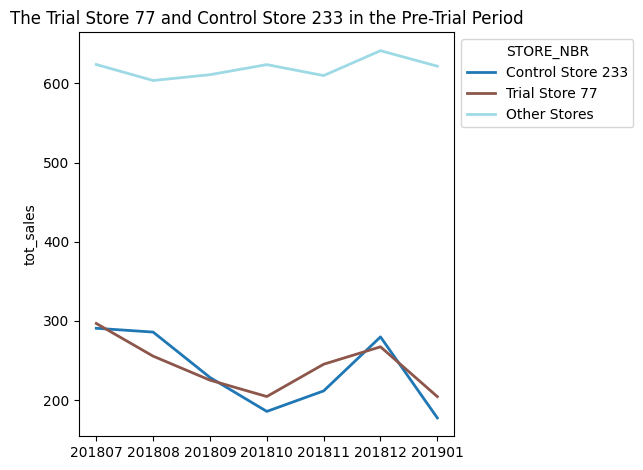

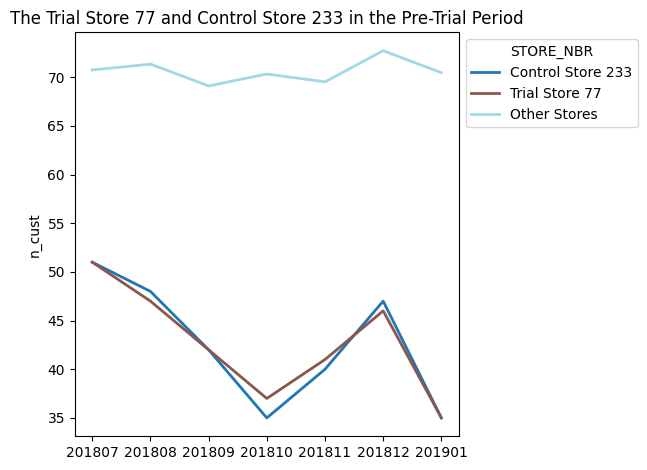

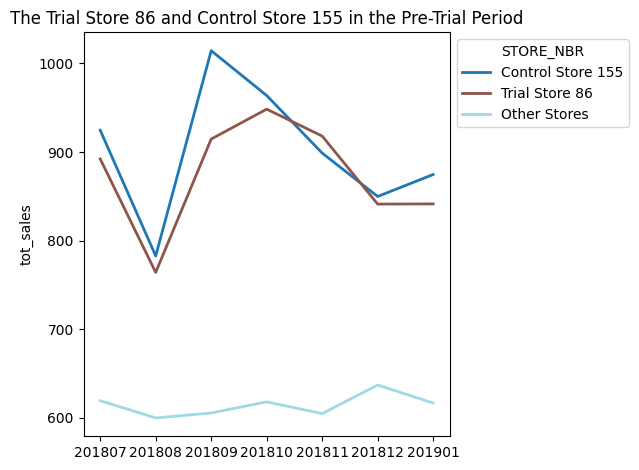

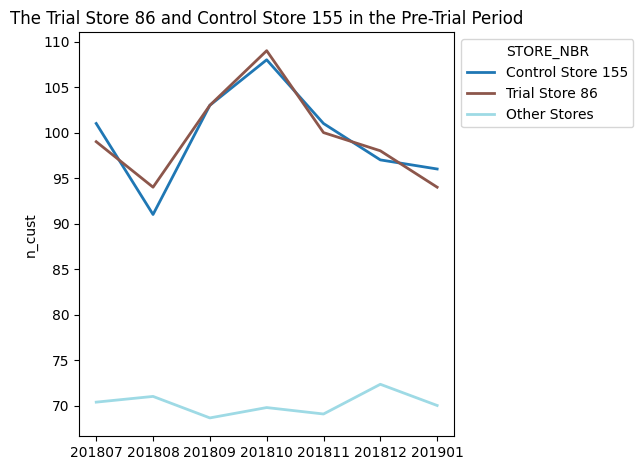

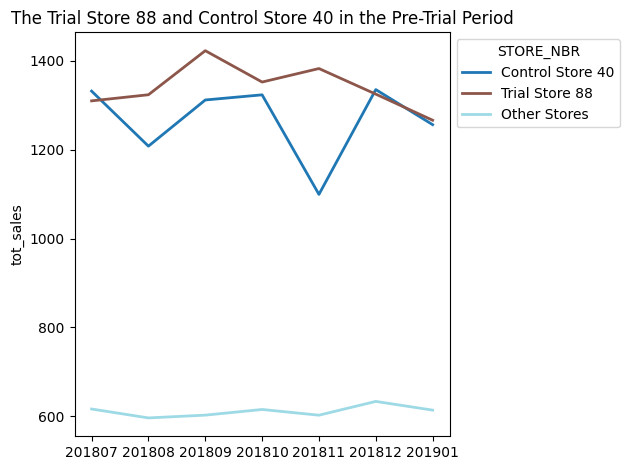

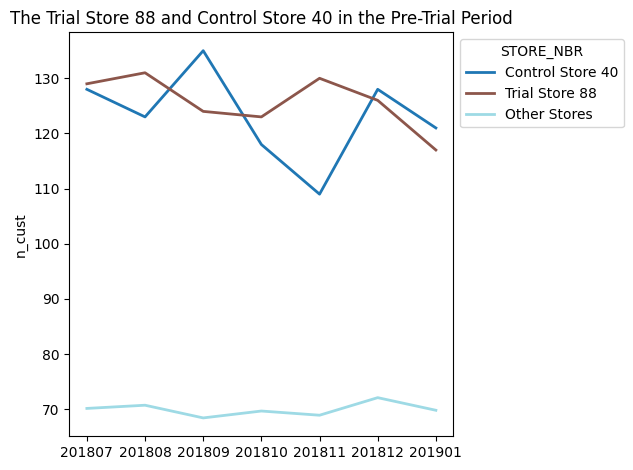

In [15]:
storepair = [[77, 233], [86, 155], [88, 40]]
metric_cols = ['tot_sales', 'n_cust']

for pair in storepair:
    for metric in metric_cols:
        make_plots(pair, metric)


The trial and control stores exhibit broadly comparable performance across all key metrics during the pre-trial period.

We now move on to assessing whether the trial generated an uplift in chip sales. To do this, we first scale the control store's sales to the trial store’s level to account for any underlying differences unrelated to the trial itself.

In [16]:
# Calculate the scaling factor for the store pairs
scale_store77 = pretrial_metrics[pretrial_metrics.STORE_NBR == 77]['tot_sales'].sum()/pretrial_metrics[pretrial_metrics.STORE_NBR == 233]['tot_sales'].sum()
scale_store86 = pretrial_metrics[pretrial_metrics.STORE_NBR == 86]['tot_sales'].sum()/pretrial_metrics[pretrial_metrics.STORE_NBR == 155]['tot_sales'].sum()
scale_store88 = pretrial_metrics[pretrial_metrics.STORE_NBR == 88]['tot_sales'].sum()/pretrial_metrics[pretrial_metrics.STORE_NBR == 40]['tot_sales'].sum()

In [17]:
# Extract the control store data from the df and scale according to the store 
scaled_control233 = metrics_df[metrics_df.STORE_NBR.isin([233])][['STORE_NBR', "YEARMONTH", 'tot_sales']]
scaled_control233.tot_sales *= scale_store77
scaled_control155 = metrics_df[metrics_df.STORE_NBR.isin([155])][['STORE_NBR', "YEARMONTH", 'tot_sales']]
scaled_control155.tot_sales *= scale_store86
scaled_control40 = metrics_df[metrics_df.STORE_NBR.isin([40])][['STORE_NBR', "YEARMONTH", 'tot_sales']]
scaled_control40.tot_sales *= scale_store88

# Combine the scaled control stores to a single df
scaledsales_control = pd.concat([scaled_control233, scaled_control155, scaled_control40]).reset_index(drop = True)
scaledsales_control = scaledsales_control.rename(columns = {'tot_sales':'scaled_tot_sales', 'STORE_NBR': 'CONTROL_NBR'}) 
# Get the trial period of scaled control stores 
scaledsales_control_trial = scaledsales_control[(scaledsales_control.YEARMONTH>=201902) & (scaledsales_control.YEARMONTH<=201904)].reset_index(drop = True)

# Get the trial period of the trial stores 
trialsales = metrics_df[metrics_df.STORE_NBR.isin([77,86,88])][['STORE_NBR', "YEARMONTH", 'tot_sales']].reset_index(drop = True)
trialsales = trialsales.rename(columns = {'STORE_NBR': 'TRIAL_NBR'}) 
trialsales_trial = trialsales[(trialsales.YEARMONTH >= 201902) & (trialsales.YEARMONTH <= 201904)].reset_index(drop = True)

After aligning the control store’s sales to the trial store baseline, we can quantify the percentage gap between the scaled control sales and the trial store’s actual sales during the trial period.

In [18]:
# Calculate the percentage difference between the control and trial store pairs for each month over the year   
percentdiff = scaledsales_control.copy()
percentdiff[['TRIAL_NBR', 'tot_sales_t']] = trialsales[['TRIAL_NBR', 'tot_sales']]
percentdiff = percentdiff.rename(columns = {'scaled_tot_sales' : 'scaled_sales_c'})
percentdiff['sales_percent_diff'] = (percentdiff.tot_sales_t-percentdiff.scaled_sales_c)\
                                    /(0.5*((percentdiff.scaled_sales_c+percentdiff.tot_sales_t)))
percentdiff.head()

,CONTROL_NBR,YEARMONTH,scaled_sales_c,TRIAL_NBR,tot_sales_t,sales_percent_diff
0,233,201807,297.565550,77,296.8,-0.002576
1,233,201808,292.652187,77,255.5,-0.135554
2,233,201809,233.998916,77,225.2,-0.038323
3,233,201810,190.085733,77,204.5,0.073060
4,233,201811,216.597421,77,245.3,0.124281


Let's see if the difference is significant using a t-test. Our null hypothesis is that the trial period is the same as the pre-trial period; we will test with a null hypothesis that there is a 0-percent between the trial and control stores.

In [19]:
# As our null hypothesis is that the trial period is the same as the pre-trial period,
# Take the standard deviation based on the scaled percentage difference in the pre-trial period.
pretrial_percentdiff = percentdiff[percentdiff.YEARMONTH < 201902]
pretrial_percentdiff_std = pretrial_percentdiff.groupby(['TRIAL_NBR'])['sales_percent_diff'].agg('std').reset_index()
dof = 6 # 7 months of data - 1 

for stores in storepair: # stores numbers are stored as [trial, control] in storepair
    trialstore = stores[0]
    controlstore = stores[1]
    pretrial = percentdiff[(percentdiff.YEARMONTH < 201902) & (percentdiff.TRIAL_NBR == trialstore)]
    std = pretrial['sales_percent_diff'].agg('std')
    mean =  pretrial['sales_percent_diff'].agg('mean')
    trialperiod = percentdiff[(percentdiff.YEARMONTH >= 201902) & (percentdiff.YEARMONTH <= 201904) \
                              & (percentdiff.TRIAL_NBR == trialstore)]
    print("Trial store -", trialstore, "; control store -", controlstore)
    print("Month : t-statistic")
    for month in trialperiod.YEARMONTH.unique():
        xval = trialperiod[trialperiod.YEARMONTH == month]['sales_percent_diff'].item()
        tstat = ((xval - mean)/std)
        print(str(month), ' : ', tstat)
    print()
    
# Generate the t-statistic for the 95% percentile with 6 dof
print ('95th percentile value:', stats.t.ppf(1-0.05, 6))

Trial store - 77 ; control store - 233
Month : t-statistic
201902  :  -0.7171038288055838
201903  :  3.035317928855674
201904  :  4.708944418758219

Trial store - 86 ; control store - 155
Month : t-statistic
201902  :  1.4133618775921597
201903  :  7.123063846042147
201904  :  0.8863824572944234

Trial store - 88 ; control store - 40
Month : t-statistic
201902  :  -0.5481633746817577
201903  :  1.0089992743637823
201904  :  0.9710006270463672

95th percentile value: 1.9431802803927816


- The t-value for Trial Store 77 in March and April exceeds the 95% critical value, indicating that its sales uplift during these months is statistically significant relative to the control store.

- Trial Store 86 also shows a statistically significant uplift in March, with its t-value surpassing the 95th percentile threshold.

- These results suggest that the trial intervention drove meaningful sales increases in these periods. To visualise this effect, we will plot the trial store sales, scaled control store sales, and the 95th percentile control-store threshold.

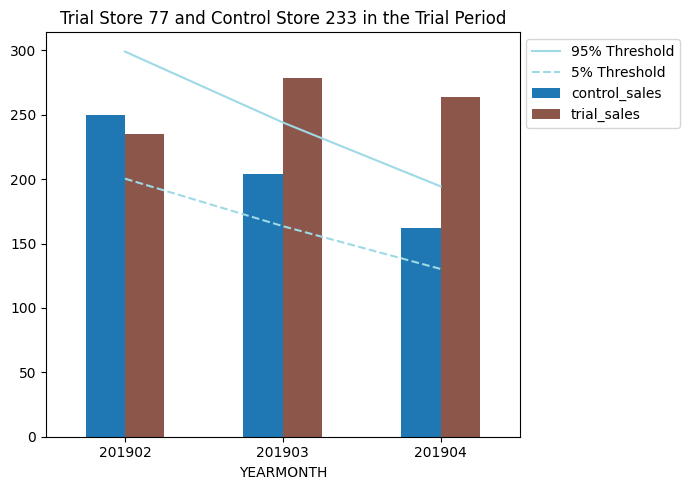

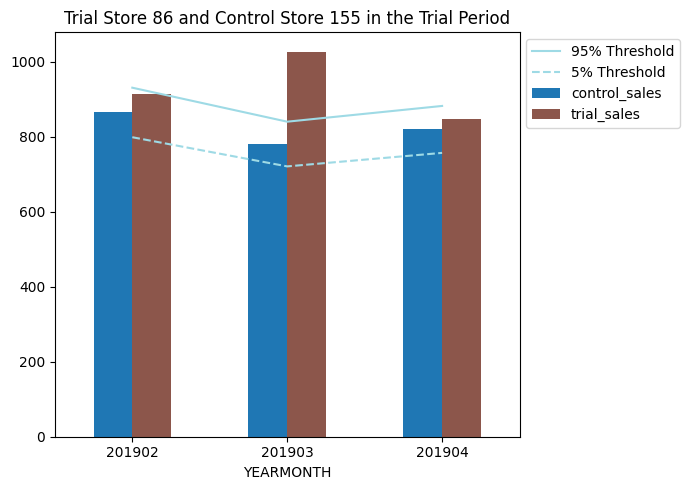

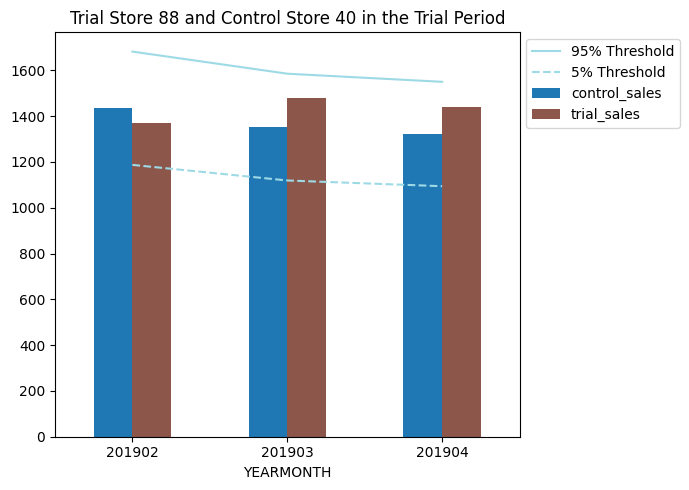

In [24]:
# First do bar graphs during the trial period
storepair = [[77, 233], [86, 155], [88, 40]]

# Define tab20 colormap colours
cmap = plt.cm.tab20
color_control = cmap(0)    # Control bar colour
color_trial   = cmap(10)   # Trial bar colour
color_other   = cmap(19)   # Threshold line colour

for stores in storepair:  # stores numbers are stored as [trial, control] in storepair
    
    trial = stores[0]
    control = stores[1]
    
    # Plot the bar chart of sales performance 
    plot_control = percentdiff[
        (percentdiff['CONTROL_NBR'] == control) & 
        (percentdiff.YEARMONTH >= 201902) & 
        (percentdiff.YEARMONTH <= 201904)
    ][['YEARMONTH', 'CONTROL_NBR', 'scaled_sales_c']]
    
    plot_control = plot_control.rename(columns={
        "CONTROL_NBR": "STORE_NBR",
        "scaled_sales_c": "control_sales"
    })
    
    plot_trial = percentdiff[
        (percentdiff['TRIAL_NBR'] == trial) & 
        (percentdiff.YEARMONTH >= 201902) & 
        (percentdiff.YEARMONTH <= 201904)
    ][['YEARMONTH', 'TRIAL_NBR', 'tot_sales_t']]
    
    plot_trial = plot_trial.rename(columns={
        "TRIAL_NBR": "STORE_NBR",
        "tot_sales_t": "trial_sales"
    })

    # Merge into single bar DataFrame
    toplot = (
        plot_control[["YEARMONTH", "control_sales"]]
        .merge(plot_trial[["YEARMONTH", "trial_sales"]], on="YEARMONTH")
        .set_index("YEARMONTH")
    )
    
    # ---- FIX BAR COLORS WITH tab20 ----
    ax = toplot.plot(
        kind='bar', 
        figsize=(7, 5),
        color=[color_control, color_trial]   # <--- updated colors
    )
    
    # Compute 95% thresholds
    std = percentdiff[
        (percentdiff['CONTROL_NBR'] == control) &
        (percentdiff.YEARMONTH < 201902)
    ]['sales_percent_diff'].std()

    threshold95 = plot_control.reset_index()[['YEARMONTH', 'control_sales']]
    threshold95.control_sales = threshold95.control_sales * (1 + std * 2)

    threshold5 = plot_control.reset_index()[['YEARMONTH', 'control_sales']]
    threshold5.control_sales = threshold5.control_sales * (1 - std * 2)

    # ---- FIX THRESHOLD LINE COLORS WITH tab20 ----
    threshold95.plot.line(
        x='YEARMONTH', 
        y='control_sales',
        color=color_other,       # <--- tab20(19)
        figsize=(7, 5),
        use_index=False, 
        ax=ax,
        label='95% Threshold'
    )

    threshold5.plot.line(
        x='YEARMONTH', 
        y='control_sales',
        color=color_other,       # <--- tab20(19)
        figsize=(7, 5),
        use_index=False, 
        ax=ax,
        linestyle='--',
        label='5% Threshold'
    )
    
    # Plot formatting
    plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
    titlestr = f"Trial Store {trial} and Control Store {control} in the Trial Period"
    ax.set_title(titlestr)
    
    plt.tight_layout()
    plt.show()


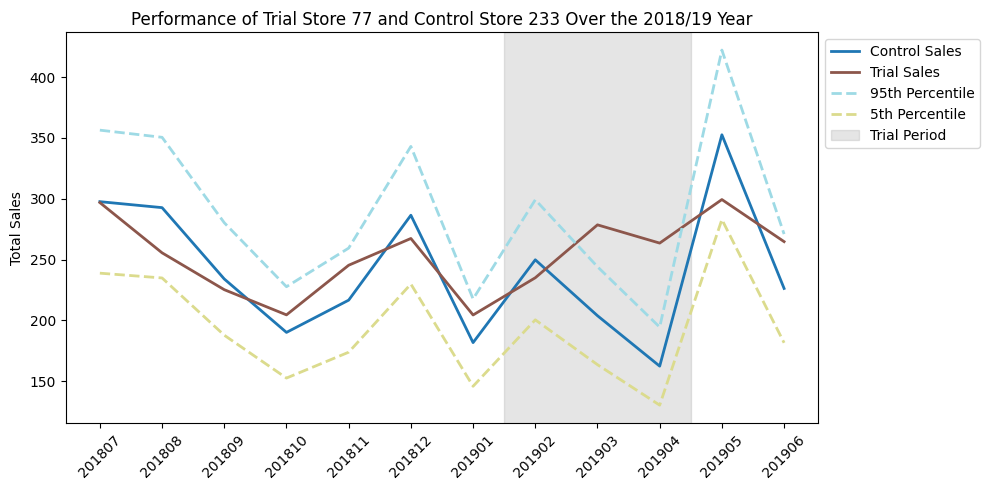

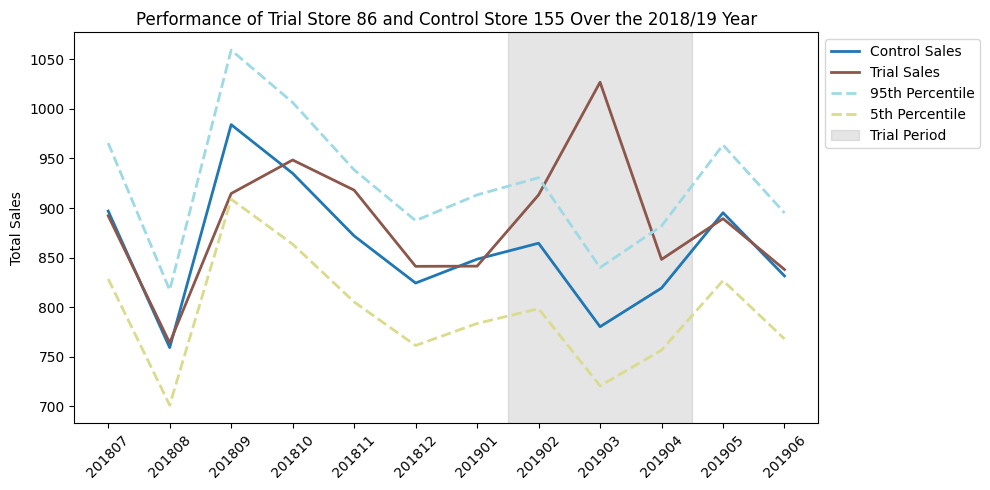

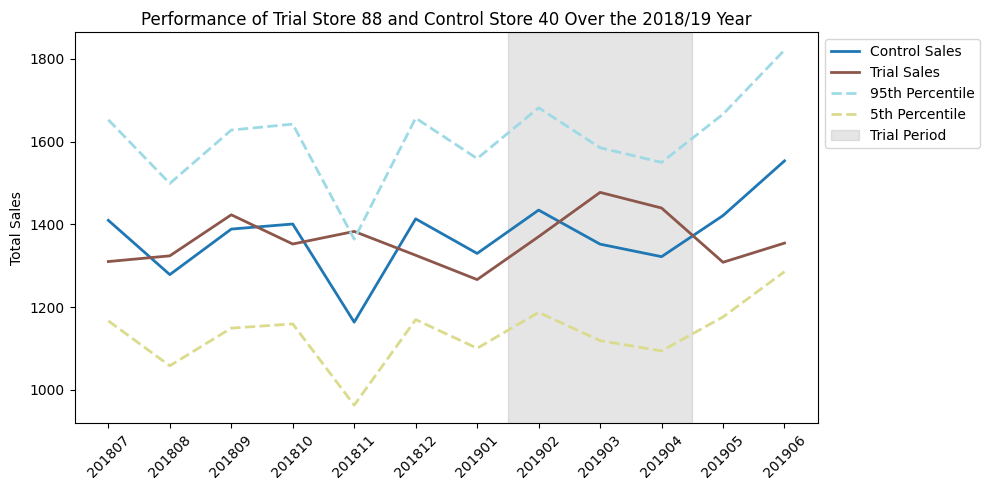

In [26]:
# Then do line graphs during the whole year - for the report 
from matplotlib.patches import Rectangle

# Define tab20 colormap colours
cmap = plt.cm.tab20
color_control = cmap(0)     # Control store line
color_trial   = cmap(10)    # Trial store line
color_95      = cmap(19)    # 95% threshold line
color_5       = cmap(17)    # 5% threshold line  <-- NEW COLOR

storepair = [[77, 233], [86, 155], [88, 40]]

for stores in storepair:
    
    trial = stores[0]
    control = stores[1]

    # ---- Plot control and trial data ----
    plot_control = percentdiff[
        percentdiff['CONTROL_NBR'] == control
    ][['YEARMONTH', 'CONTROL_NBR', 'scaled_sales_c']].rename(
        columns={"CONTROL_NBR": "STORE_NBR", "scaled_sales_c": "control_sales"}
    )

    plot_trial = percentdiff[
        percentdiff['TRIAL_NBR'] == trial
    ][['YEARMONTH', 'TRIAL_NBR', 'tot_sales_t']].rename(
        columns={"TRIAL_NBR": "STORE_NBR", "tot_sales_t": "trial_sales"}
    )

    # ---- Line colors ----
    ax = plot_control.plot.line(
        x="YEARMONTH",
        y="control_sales",
        label="Control Sales",
        use_index=False,
        figsize=(10, 5),
        color=color_control,
        linewidth=2
    )

    plot_trial.plot.line(
        x="YEARMONTH",
        y="trial_sales",
        label="Trial Sales",
        ax=ax,
        use_index=False,
        color=color_trial,
        linewidth=2
    )

    # ---- Compute thresholds ----
    std = percentdiff[
        (percentdiff['CONTROL_NBR'] == control) &
        (percentdiff.YEARMONTH < 201902)
    ]['sales_percent_diff'].std()

    threshold95 = plot_control.reset_index()[['YEARMONTH', 'control_sales']]
    threshold95.control_sales *= (1 + std * 2)

    threshold5 = plot_control.reset_index()[['YEARMONTH', 'control_sales']]
    threshold5.control_sales *= (1 - std * 2)

    # ---- Plot threshold lines with different colors ----
    threshold95.plot.line(
        x='YEARMONTH',
        y='control_sales',
        linestyle='--',
        color=color_95,         # Changed
        linewidth=2,
        use_index=False,
        ax=ax,
        label='95th Percentile'
    )

    threshold5.plot.line(
        x='YEARMONTH',
        y='control_sales',
        linestyle='--',
        color=color_5,          # NEW COLOR
        linewidth=2,
        use_index=False,
        ax=ax,
        label='5th Percentile'
    )

    # ---- Highlight trial period ----
    ax.add_patch(
        Rectangle(
            (6.5, 0),
            3,
            ax.get_ylim()[1],
            alpha=0.2,
            color="grey",
            label="Trial Period"
        )
    )

    # Formatting
    ax.set_ylabel('Total Sales')
    plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

    titlestr = f"Performance of Trial Store {trial} and Control Store {control} Over the 2018/19 Year"
    ax.set_title(titlestr)

    positions = range(12)
    labels = ("201807", "201808", "201809", "201810", "201811", "201812",
              "201901", "201902", "201903", "201904", "201905", "201906")
    plt.xticks(positions, labels, rotation=45)

    plt.tight_layout()
    plt.show()


Insights from Trial vs Control Store Comparison (Sales Performance)

- Store 77
  - The trial store’s sales exceeded the control store’s 5%–95% confidence interval in two of the three trial months, indicating a statistically significant uplift.
  - This suggests the trial intervention had a strong and consistent positive impact on store performance.

- Store 86
  - A significant uplift is observed only in March, where sales clearly exceeded the control store’s confidence interval.
  - February and April do not show meaningful deviation, implying that the impact of the trial for this store is limited or inconsistent across the trial period.

- Store 88
  - The trial store’s sales remained fully within the control store’s confidence interval throughout the trial.
  - This indicates no measurable uplift attributable to the trial intervention for this location.

In [30]:
# Calculate the scaling factor for the store pairs
scale_store77 = pretrial_metrics[pretrial_metrics.STORE_NBR == 77]['n_cust'].sum()/pretrial_metrics[pretrial_metrics.STORE_NBR == 233]['n_cust'].sum()
scale_store86 = pretrial_metrics[pretrial_metrics.STORE_NBR == 86]['n_cust'].sum()/pretrial_metrics[pretrial_metrics.STORE_NBR == 155]['n_cust'].sum()
scale_store88 = pretrial_metrics[pretrial_metrics.STORE_NBR == 88]['n_cust'].sum()/pretrial_metrics[pretrial_metrics.STORE_NBR == 40]['n_cust'].sum()

In [31]:
# Extract the control store data from the df and scale according to the store 
scaled_control233 = metrics_df[metrics_df.STORE_NBR.isin([233])][['STORE_NBR', "YEARMONTH", 'n_cust']]
scaled_control233.n_cust *= scale_store77
scaled_control155 = metrics_df[metrics_df.STORE_NBR.isin([155])][['STORE_NBR', "YEARMONTH", 'n_cust']]
scaled_control155.n_cust *= scale_store86
scaled_control40 = metrics_df[metrics_df.STORE_NBR.isin([40])][['STORE_NBR', "YEARMONTH", 'n_cust']]
scaled_control40.n_cust *= scale_store88

# Combine the scaled control stores to a single df
scaledncust_control = pd.concat([scaled_control233, scaled_control155, scaled_control40]).reset_index(drop = True)
scaledncust_control = scaledncust_control.rename(columns = {'n_cust':'scaled_n_cust', 'STORE_NBR': 'CONTROL_NBR'}) 
# Get the trial period of scaled control stores 
scaledncust_control_trial = scaledncust_control[(scaledsales_control.YEARMONTH>=201902) & (scaledsales_control.YEARMONTH<=201904)].reset_index(drop = True)

# Get the trial period of the trial stores 
trialncust = metrics_df[metrics_df.STORE_NBR.isin([77,86,88])][['STORE_NBR', "YEARMONTH", 'n_cust']].reset_index(drop = True)
trialncust = trialncust.rename(columns = {'STORE_NBR': 'TRIAL_NBR'}) 
trialncust_trial = trialncust[(trialncust.YEARMONTH >= 201902) & (trialsales.YEARMONTH <= 201904)].reset_index(drop = True)

In [32]:
# Calculate the percentage difference between the control and trial store pairs for each month over the year   
percentdiff = scaledncust_control.copy()
percentdiff[['TRIAL_NBR', 'n_cust_t']] = trialncust[['TRIAL_NBR', 'n_cust']]
percentdiff = percentdiff.rename(columns = {'scaled_n_cust' : 'scaled_n_cust_c'})
percentdiff['cust_percent_diff'] = (percentdiff.n_cust_t-percentdiff.scaled_n_cust_c)\
                                    /(0.5*((percentdiff.scaled_n_cust_c+percentdiff.n_cust_t)))
percentdiff.head()

,CONTROL_NBR,YEARMONTH,scaled_n_cust_c,TRIAL_NBR,n_cust_t,cust_percent_diff
0,233,201807,51.171141,77,51,-0.003350
1,233,201808,48.161074,77,47,-0.024402
2,233,201809,42.140940,77,42,-0.003350
3,233,201810,35.117450,77,37,0.052208
4,233,201811,40.134228,77,41,0.021342


In [33]:
# As our null hypothesis is that the trial period is the same as the pre-trial period,
# let's take the standard deviation based on the scaled percentage difference in the pre-trial period.
pretrial_percentdiff = percentdiff[percentdiff.YEARMONTH < 201902]
pretrial_percentdiff_std = pretrial_percentdiff.groupby(['TRIAL_NBR'])['cust_percent_diff'].agg('std').reset_index()
dof = 6 # 7 months of data - 1 

for stores in storepair: # stores numbers are stored as [trial, control] in storepair
    trialstore = stores[0]
    controlstore = stores[1]
    pretrial = percentdiff[(percentdiff.YEARMONTH < 201902) & (percentdiff.TRIAL_NBR == trialstore)]
    std = pretrial['cust_percent_diff'].agg('std')
    mean =  pretrial['cust_percent_diff'].agg('mean')
    trialperiod = percentdiff[(percentdiff.YEARMONTH >= 201902) & (percentdiff.YEARMONTH <= 201904) \
                              & (percentdiff.TRIAL_NBR == trialstore)]
    print("Trial store -", trialstore, "; control store -", controlstore)
    print("Month : t-statistic")
    for month in trialperiod.YEARMONTH.unique():
        xval = trialperiod[trialperiod.YEARMONTH == month]['cust_percent_diff'].item()
        tstat = ((xval - mean)/std)
        print(str(month), ' : ', tstat)
    print()
    
# Generate the t-statistic for the 95% percentile with 6 dof
print ('95th percentile value:', stats.t.ppf(1-0.05, 6))

Trial store - 77 ; control store - 233
Month : t-statistic
201902  :  -0.19886295797440687
201903  :  8.009609025380932
201904  :  16.114474772873923

Trial store - 86 ; control store - 155
Month : t-statistic
201902  :  6.220524882227514
201903  :  10.52599074274189
201904  :  3.0763575852842706

Trial store - 88 ; control store - 40
Month : t-statistic
201902  :  -0.3592881735131531
201903  :  1.2575196020616801
201904  :  0.6092905590514273

95th percentile value: 1.9431802803927816


- Trial Store 77 shows statistically significant increases in customer numbers, with its results in at least two trial months exceeding the 95% confidence interval of the control store — indicating a meaningful uplift in customer traffic during the intervention.
- Trial Store 86 also demonstrates a significant uplift in customer count, with at least two months falling outside the control store’s confidence range, suggesting the trial had a positive effect on attracting more customers.
- Trial Store 88 does not exhibit any significant changes, as customer numbers remain within the expected range of the control store across all trial months.

To better illustrate these differences, we will plot the customer counts for both trial and control stores, along with the 95th-percentile threshold of the control store, to visually highlight where statistically significant uplift occurs.

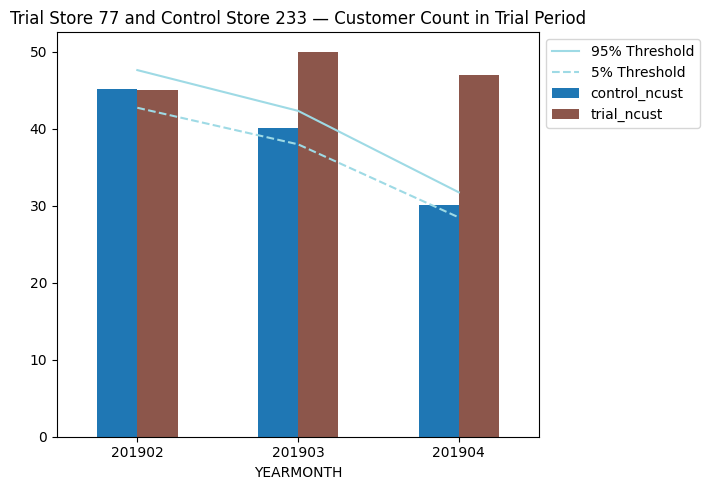

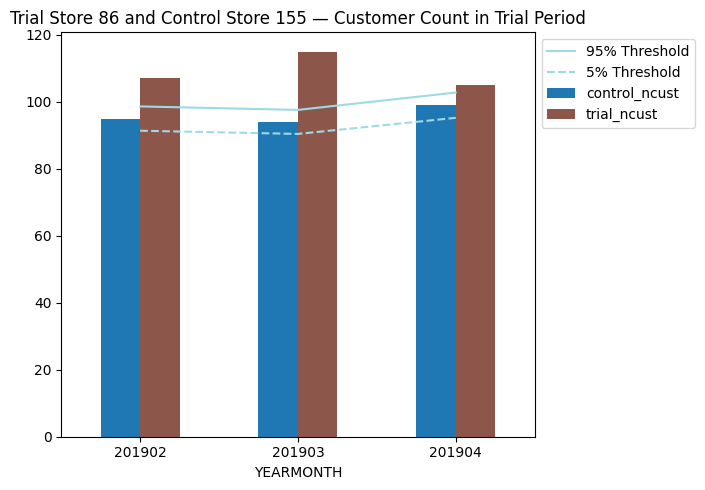

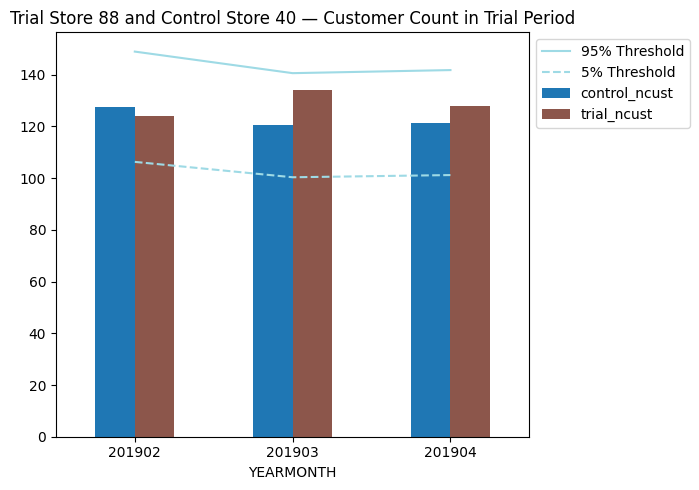

In [34]:
# First do bar charts to focus on the trial period (Customer Count)
storepair = [[77, 233], [86, 155], [88, 40]]

# Define tab20 colormap colours
cmap = plt.cm.tab20
color_control = cmap(0)     # Control bar colour
color_trial   = cmap(10)    # Trial bar colour
color_other   = cmap(19)    # Threshold line colour

for stores in storepair:  # stores numbers are stored as [trial, control]

    trial = stores[0]
    control = stores[1]

    # Control customer count for trial period
    plot_control = percentdiff[
        (percentdiff['CONTROL_NBR'] == control) &
        (percentdiff.YEARMONTH >= 201902) &
        (percentdiff.YEARMONTH <= 201904)
    ][['YEARMONTH', 'CONTROL_NBR', 'scaled_n_cust_c']]

    plot_control = plot_control.rename(columns={
        "CONTROL_NBR": "STORE_NBR",
        "scaled_n_cust_c": "control_ncust"
    })

    # Trial customer count for trial period
    plot_trial = percentdiff[
        (percentdiff['TRIAL_NBR'] == trial) &
        (percentdiff.YEARMONTH >= 201902) &
        (percentdiff.YEARMONTH <= 201904)
    ][['YEARMONTH', 'TRIAL_NBR', 'n_cust_t']]

    plot_trial = plot_trial.rename(columns={
        "TRIAL_NBR": "STORE_NBR",
        "n_cust_t": "trial_ncust"
    })

    # Merge both into one bar chart table
    toplot = (
        plot_control[['YEARMONTH', 'control_ncust']]
        .merge(plot_trial[['YEARMONTH', 'trial_ncust']], on="YEARMONTH")
        .set_index("YEARMONTH")
    )

    # ---- FIX BAR COLORS WITH tab20 ----
    ax = toplot.plot(
        kind='bar',
        figsize=(7, 5),
        color=[color_control, color_trial]    # <--- consistent colors
    )

    # Compute standard deviation for threshold
    std = percentdiff[
        (percentdiff['CONTROL_NBR'] == control) &
        (percentdiff.YEARMONTH < 201902)
    ]['cust_percent_diff'].std()

    # Upper 95% threshold
    threshold95 = plot_control.reset_index()[['YEARMONTH', 'control_ncust']]
    threshold95.control_ncust = threshold95.control_ncust * (1 + std * 2)

    # Lower 5% threshold
    threshold5 = plot_control.reset_index()[['YEARMONTH', 'control_ncust']]
    threshold5.control_ncust = threshold5.control_ncust * (1 - std * 2)

    # ---- FIX THRESHOLD LINE COLORS WITH tab20 ----
    threshold95.plot.line(
        x='YEARMONTH',
        y='control_ncust',
        color=color_other,            # <--- tab20(19)
        figsize=(7, 5),
        use_index=False,
        ax=ax,
        label='95% Threshold'
    )

    threshold5.plot.line(
        x='YEARMONTH',
        y='control_ncust',
        color=color_other,            # <--- tab20(19)
        linestyle='--',
        figsize=(7, 5),
        use_index=False,
        ax=ax,
        label='5% Threshold'
    )

    # Formatting
    plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
    titlestr = f"Trial Store {trial} and Control Store {control} — Customer Count in Trial Period"
    ax.set_title(titlestr)

    plt.tight_layout()
    plt.show()


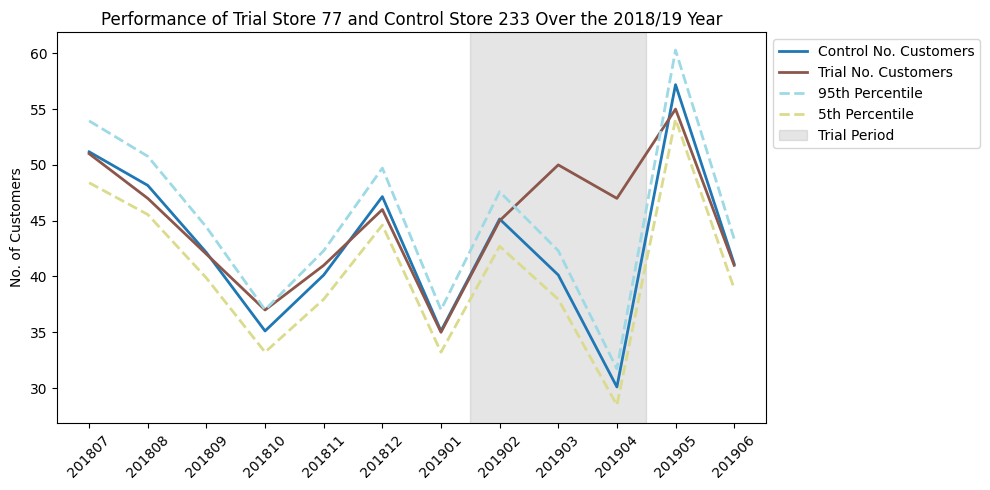

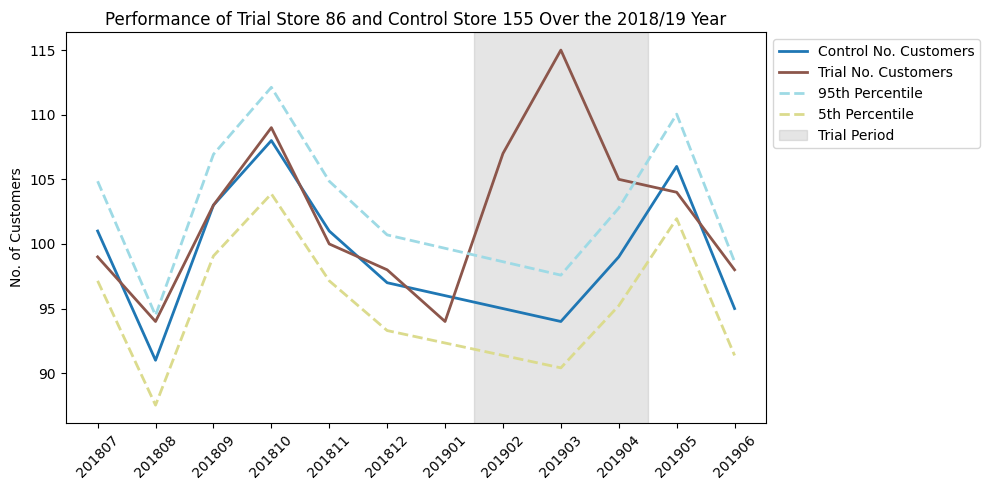

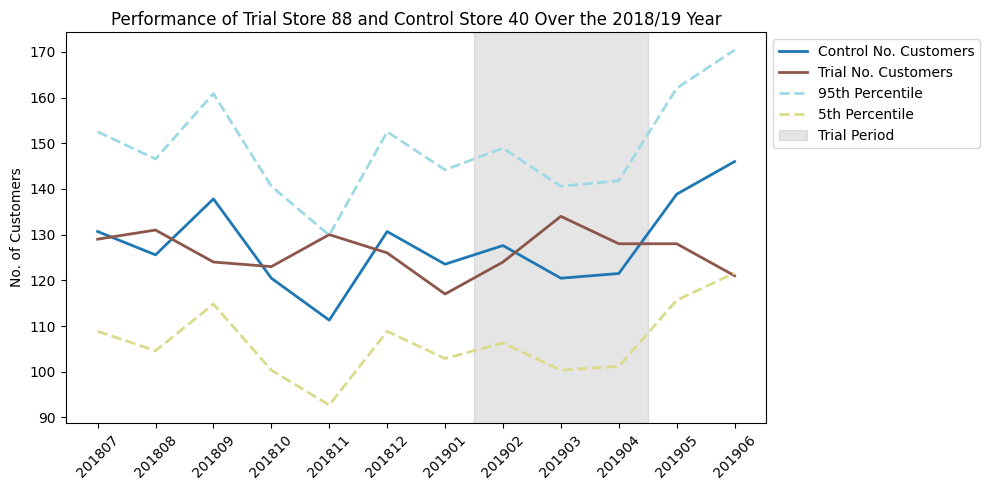

In [35]:
# Then do line graphs to show a full year's trend (Customer Count)
from matplotlib.patches import Rectangle

# Define tab20 colormap colours
cmap = plt.cm.tab20
color_control = cmap(0)     # Control store line
color_trial   = cmap(10)    # Trial store line
color_95      = cmap(19)    # 95% threshold line
color_5       = cmap(17)    # 5% threshold line

storepair = [[77, 233], [86, 155], [88, 40]]

for stores in storepair:
    
    trial = stores[0]
    control = stores[1]

    # ---- Plot control and trial data ----
    plot_control = percentdiff[
        percentdiff['CONTROL_NBR'] == control
    ][['YEARMONTH', 'CONTROL_NBR', 'scaled_n_cust_c']].rename(
        columns={"CONTROL_NBR": "STORE_NBR", "scaled_n_cust_c": "control_ncust"}
    )

    plot_trial = percentdiff[
        percentdiff['TRIAL_NBR'] == trial
    ][['YEARMONTH', 'TRIAL_NBR', 'n_cust_t']].rename(
        columns={"TRIAL_NBR": "STORE_NBR", "n_cust_t": "trial_ncust"}
    )

    # ---- Line colors ----
    ax = plot_control.plot.line(
        x="YEARMONTH",
        y="control_ncust",
        label="Control No. Customers",
        use_index=False,
        figsize=(10, 5),
        color=color_control,
        linewidth=2
    )

    plot_trial.plot.line(
        x="YEARMONTH",
        y="trial_ncust",
        label="Trial No. Customers",
        ax=ax,
        use_index=False,
        color=color_trial,
        linewidth=2
    )

    # ---- Compute thresholds ----
    std = percentdiff[
        (percentdiff['CONTROL_NBR'] == control) &
        (percentdiff.YEARMONTH < 201902)
    ]['cust_percent_diff'].std()

    threshold95 = plot_control.reset_index()[['YEARMONTH', 'control_ncust']]
    threshold95.control_ncust *= (1 + std * 2)

    threshold5 = plot_control.reset_index()[['YEARMONTH', 'control_ncust']]
    threshold5.control_ncust *= (1 - std * 2)

    # ---- Plot threshold lines with different colors ----
    threshold95.plot.line(
        x='YEARMONTH',
        y='control_ncust',
        linestyle='--',
        color=color_95,
        linewidth=2,
        use_index=False,
        ax=ax,
        label='95th Percentile'
    )

    threshold5.plot.line(
        x='YEARMONTH',
        y='control_ncust',
        linestyle='--',
        color=color_5,
        linewidth=2,
        use_index=False,
        ax=ax,
        label='5th Percentile'
    )

    # ---- Highlight trial period ----
    ax.add_patch(
        Rectangle(
            (6.5, 0),             # Start around Feb 2019 index
            3,                    # Feb–Apr width
            ax.get_ylim()[1],     # Full height
            alpha=0.2,
            color="grey",
            label="Trial Period"
        )
    )

    # ---- Formatting ----
    ax.set_ylabel('No. of Customers')
    plt.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))

    title = f"Performance of Trial Store {trial} and Control Store {control} Over the 2018/19 Year"
    ax.set_title(title)

    positions = range(12)
    labels = ("201807", "201808", "201809", "201810", "201811", "201812",
              "201901", "201902", "201903", "201904", "201905", "201906")
    plt.xticks(positions, labels, rotation=45)

    plt.tight_layout()
    plt.show()


## **Conclusion**

- **Stores 77 and 86 recorded statistically significant increases in customer numbers** across at least two of the three trial months.  
  This indicates that the trial successfully drove additional foot traffic into these stores.

- **Store 77 showed strong performance uplift**, with both total sales and customer numbers consistently exceeding the 5–95% confidence interval of the control store.  
  This suggests that the trial intervention had a clear and meaningful commercial impact.

- **Store 86 also experienced a significant rise in customer volume**, although the uplift in total sales was not as strong.  
  This may imply:
  - Customers made lower-value purchases,  
  - The trial attracted deal-seeking shoppers, or  
  - **Promotional or pricing mechanics** reduced average transaction value.  
  It would be worthwhile to confirm with the Category Manager whether Store 86 ran specific promotions during the period.

- **Store 88 showed no statistically significant difference** in customer numbers or total sales relative to its control store.  
  This suggests that the trial had **no measurable effect** in this location and may warrant further investigation regarding execution or store conditions.